In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    average_precision_score
)

In [2]:
import pandas as pd

# Load processed datasets
fraud_df = pd.read_csv("../data/processed/fraud_processed.csv")

creditcard_df = pd.read_csv("../data/processed/creditcard_processed.csv")

# Load training and testing datasets
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")

y_test = pd.read_csv("../data/processed/y_test.csv")

In [3]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

In [4]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (187004, 202)
Testing Features : (25830, 202)
Training Labels  : (187004,)
Testing Labels   : (25830,)


In [5]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
class
0    93502
1    93502
Name: count, dtype: int64

Testing class distribution:
class
0    23376
1     2454
Name: count, dtype: int64


In [6]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [7]:
y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:, 1]

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    average_precision_score
)

print(classification_report(y_test, y_pred))

print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       0.95      0.55      0.70      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830

F1 Score: 0.6983
Average Precision: 0.6447


In [9]:
import joblib


best_rf = joblib.load("../models/best_fraud_model.pkl")

print(best_rf)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


In [10]:
y_pred = best_rf.predict(X_test)

y_prob = best_rf.predict_proba(X_test)[:, 1]

In [11]:
print(classification_report(y_test, y_pred))

print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print(f"Average Precision: {average_precision_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       0.95      0.55      0.70      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830

F1 Score: 0.6983
Average Precision: 0.6447


In [12]:
print("Number of Features:", len(X_train.columns))

print("\nFirst 20 Features:\n")

print(X_train.columns[:20])

Number of Features: 202

First 20 Features:

Index(['purchase_value', 'age', 'ip_address', 'lower_bound_ip_address',
       'upper_bound_ip_address', 'hour_of_day', 'time_since_signup',
       'transaction_frequency', 'transaction_velocity', 'source_Direct',
       'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera',
       'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria',
       'country_Angola', 'country_Antigua and Barbuda'],
      dtype='str')


In [13]:
print(X_train.columns.tolist())

['purchase_value', 'age', 'ip_address', 'lower_bound_ip_address', 'upper_bound_ip_address', 'hour_of_day', 'time_since_signup', 'transaction_frequency', 'transaction_velocity', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cap

In [14]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

In [15]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,time_since_signup,0.304621
2,ip_address,0.063693
3,lower_bound_ip_address,0.059854
4,upper_bound_ip_address,0.059691
5,hour_of_day,0.056222
1,age,0.053263
0,purchase_value,0.052634
9,source_Direct,0.027518
10,source_SEO,0.024643
197,day_of_week_Saturday,0.023687


In [16]:
print("Top 10 Most Important Features")

feature_importance.head(10)

Top 10 Most Important Features


,Feature,Importance
6,time_since_signup,0.304621
2,ip_address,0.063693
3,lower_bound_ip_address,0.059854
4,upper_bound_ip_address,0.059691
5,hour_of_day,0.056222
1,age,0.053263
0,purchase_value,0.052634
9,source_Direct,0.027518
10,source_SEO,0.024643
197,day_of_week_Saturday,0.023687


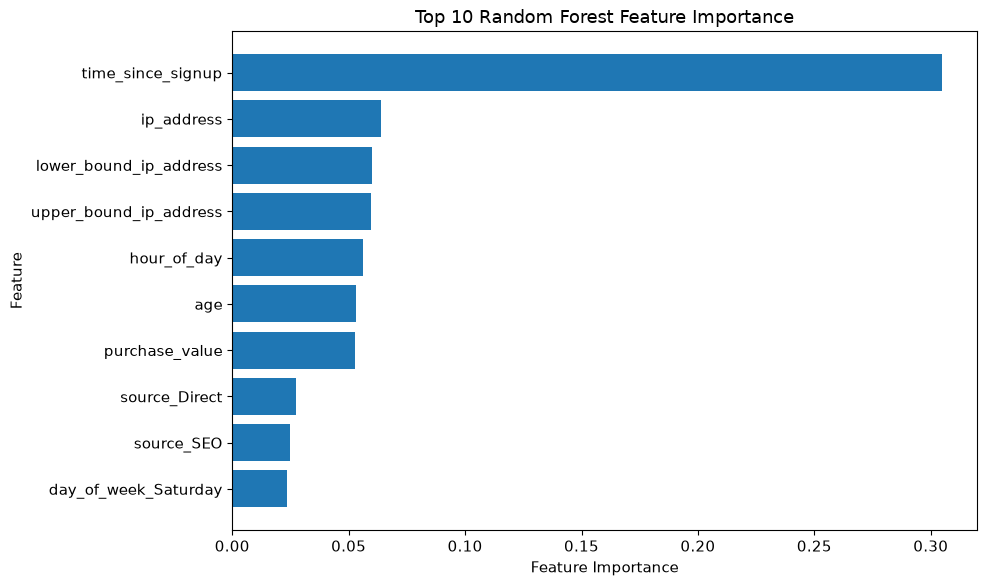

In [17]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.title("Top 10 Random Forest Feature Importance")

plt.tight_layout()

plt.show()

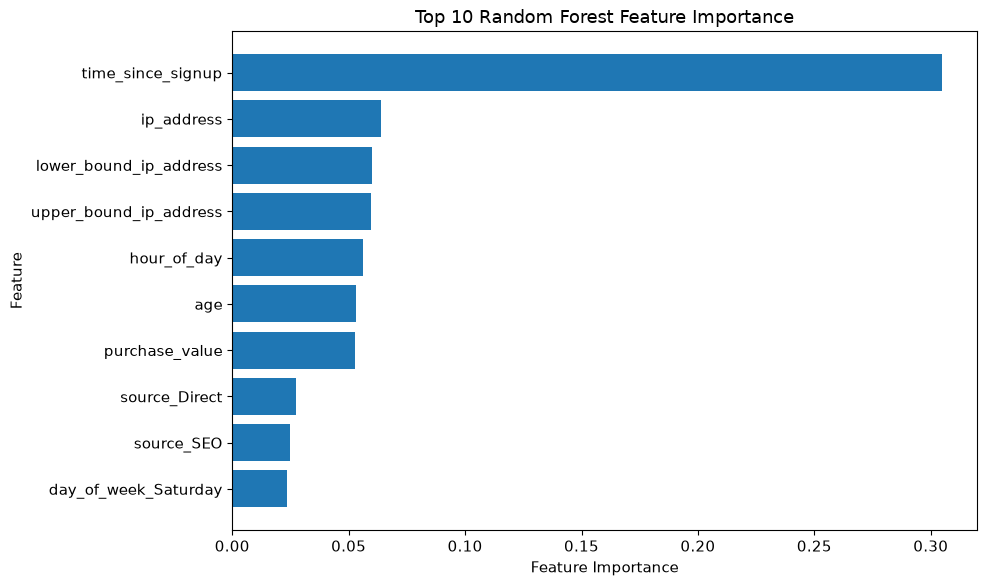

In [18]:
plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.title("Top 10 Random Forest Feature Importance")

plt.tight_layout()

plt.savefig(
    "../models/top10_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
import shap

explainer = shap.TreeExplainer(best_rf)

print("SHAP Explainer created successfully.")

SHAP Explainer created successfully.


In [20]:
X_test_sample = X_test.sample(
    n=200,
    random_state=42
)

print(X_test_sample.shape)

(200, 202)


In [21]:
explainer = shap.TreeExplainer(
    best_rf,
    feature_perturbation="tree_path_dependent"
)

print("Explainer ready")

Explainer ready


In [22]:
shap_values = explainer.shap_values(
    X_test_sample,
    check_additivity=False
)

print(type(shap_values))

<class 'numpy.ndarray'>


In [23]:
print(np.array(shap_values).shape)

(200, 202, 2)


In [24]:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

elif len(np.array(shap_values).shape) == 3:
    shap_values = shap_values[:, :, 1]


print(shap_values.shape)

(200, 202)


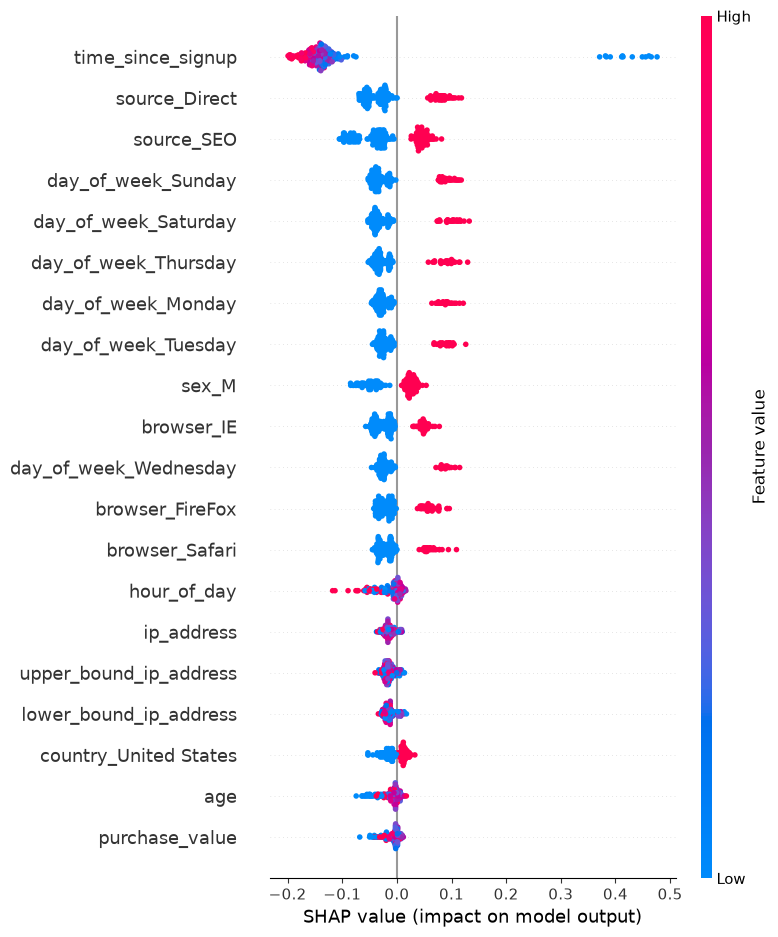

In [25]:
shap.summary_plot(
    shap_values,
    X_test_sample
)

In [26]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.savefig(
    "../models/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

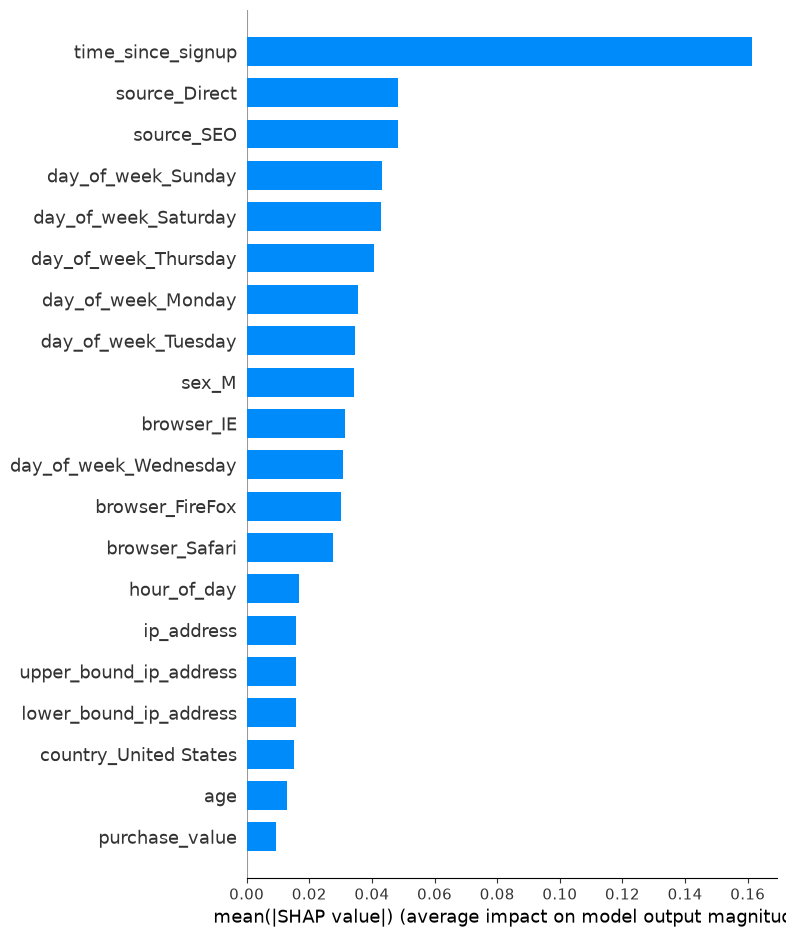

In [27]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar"
)

In [28]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    show=False
)

plt.savefig(
    "../models/shap_bar_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [29]:
mean_shap = np.abs(shap_values).mean(axis=0)


shap_importance = pd.DataFrame({
    "Feature": X_test_sample.columns,
    "Mean_SHAP": mean_shap
})


shap_importance = shap_importance.sort_values(
    by="Mean_SHAP",
    ascending=False
)


shap_importance.head(10)

,Feature,Mean_SHAP
6,time_since_signup,0.161270
9,source_Direct,0.048273
10,source_SEO,0.048211
198,day_of_week_Sunday,0.043189
197,day_of_week_Saturday,0.043053
199,day_of_week_Thursday,0.040505
196,day_of_week_Monday,0.035533
200,day_of_week_Tuesday,0.034677
15,sex_M,0.034390
12,browser_IE,0.031462


In [30]:
shap_importance.to_csv(
    "../models/shap_feature_importance.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [31]:
y_pred = best_rf.predict(X_test)

print("Predictions generated successfully")

Predictions generated successfully


In [32]:
# Convert to numpy arrays
y_test_array = np.array(y_test)
y_pred_array = np.array(y_pred)


# True Positive:
# Actual fraud and predicted fraud
tp_indices = np.where(
    (y_test_array == 1) & (y_pred_array == 1)
)[0]


# False Positive:
# Actual legitimate but predicted fraud
fp_indices = np.where(
    (y_test_array == 0) & (y_pred_array == 1)
)[0]


# False Negative:
# Actual fraud but predicted legitimate
fn_indices = np.where(
    (y_test_array == 1) & (y_pred_array == 0)
)[0]


tp_index = tp_indices[0]
fp_index = fp_indices[0]
fn_index = fn_indices[0]


print("True Positive index:", tp_index)
print("False Positive index:", fp_index)
print("False Negative index:", fn_index)

True Positive index: 3
False Positive index: 58
False Negative index: 75


In [33]:
X_explain = X_test.iloc[
    [
        tp_index,
        fp_index,
        fn_index
    ]
]


y_explain = y_test.iloc[
    [
        tp_index,
        fp_index,
        fn_index
    ]
]


pred_explain = y_pred[
    [
        tp_index,
        fp_index,
        fn_index
    ]
]


print(X_explain.shape)

print("\nActual:")
print(y_explain.values)

print("\nPrediction:")
print(pred_explain)

(3, 202)

Actual:
[1 0 1]

Prediction:
[1 1 0]


In [34]:
shap_explain = explainer.shap_values(
    X_explain,
    check_additivity=False
)


print(type(shap_explain))

<class 'numpy.ndarray'>


In [35]:
if isinstance(shap_explain, list):
    shap_explain = shap_explain[1]

elif len(np.array(shap_explain).shape) == 3:
    shap_explain = shap_explain[:, :, 1]


print(shap_explain.shape)

(3, 202)


In [38]:
# Determine the correct base value for SHAP

if isinstance(explainer.expected_value, (list, np.ndarray)):
    if np.array(explainer.expected_value).ndim == 1:
        base_value = explainer.expected_value[1]
    else:
        base_value = explainer.expected_value
else:
    base_value = explainer.expected_value

print("Base value:")
print(base_value)

Base value:
0.49995251438471894


In [39]:
print("SHAP array shape:")
print(np.array(shap_explain).shape)

SHAP array shape:
(3, 202)


<Figure size 1600x300 with 0 Axes>

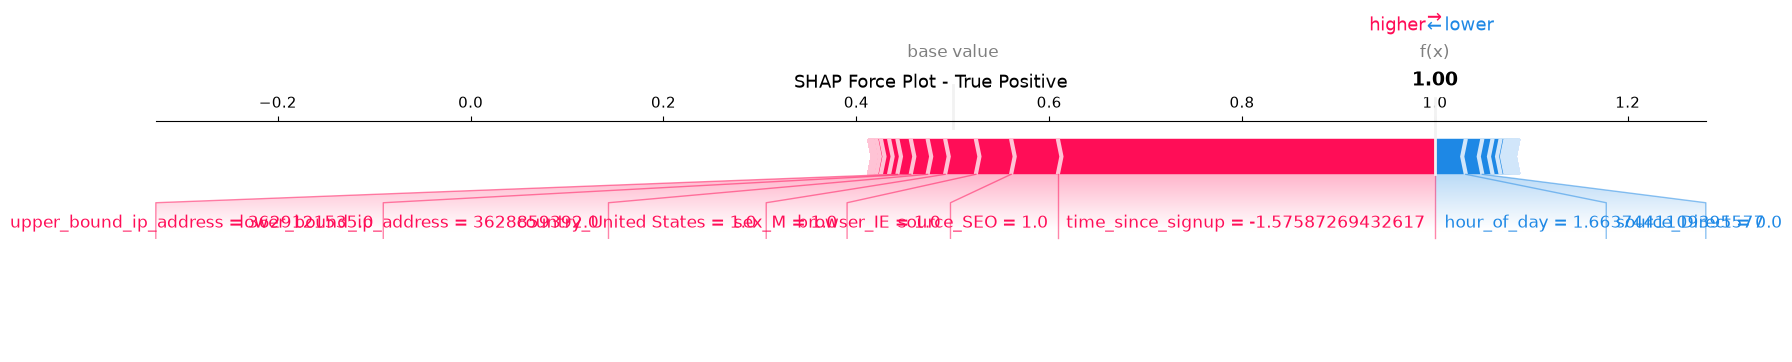

In [40]:
plt.figure(figsize=(16, 3))

shap.plots.force(
    base_value,
    shap_explain[0],
    X_explain.iloc[0],
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - True Positive")

plt.show()

In [41]:
plt.figure(figsize=(16,3))

shap.plots.force(
    base_value,
    shap_explain[0],
    X_explain.iloc[0],
    matplotlib=True,
    show=False
)

plt.savefig(
    "../models/shap_true_positive.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

<Figure size 1600x300 with 0 Axes>

<Figure size 1600x300 with 0 Axes>

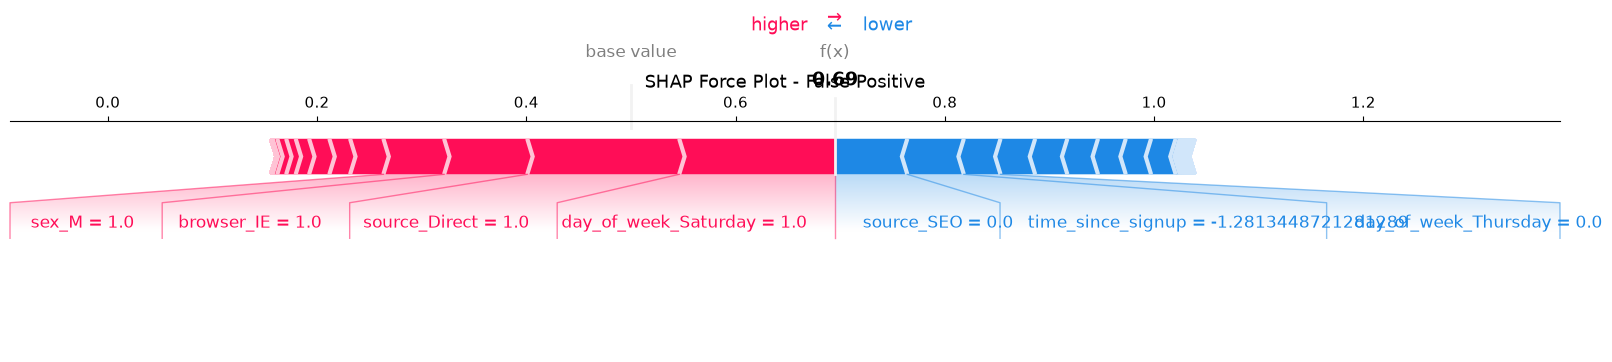

In [42]:
plt.figure(figsize=(16,3))

shap.plots.force(
    base_value,
    shap_explain[1],
    X_explain.iloc[1],
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - False Positive")

plt.show()

In [43]:
plt.figure(figsize=(16,3))

shap.plots.force(
    base_value,
    shap_explain[1],
    X_explain.iloc[1],
    matplotlib=True,
    show=False
)

plt.savefig(
    "../models/shap_false_positive.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

<Figure size 1600x300 with 0 Axes>

<Figure size 1600x300 with 0 Axes>

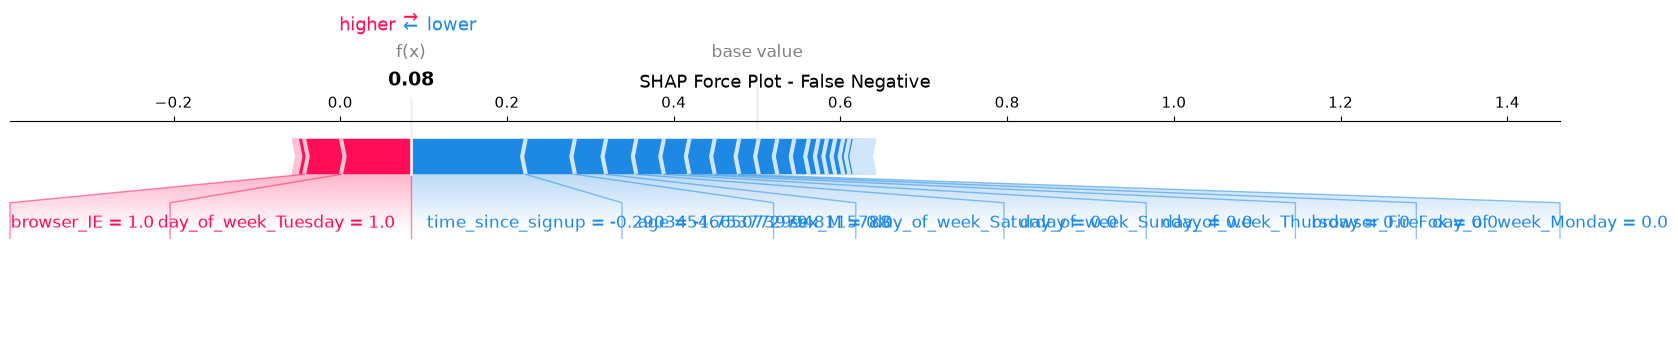

In [44]:
plt.figure(figsize=(16,3))

shap.plots.force(
    base_value,
    shap_explain[2],
    X_explain.iloc[2],
    matplotlib=True,
    show=False
)

plt.title("SHAP Force Plot - False Negative")

plt.show()

In [45]:
plt.figure(figsize=(16,3))

shap.plots.force(
    base_value,
    shap_explain[2],
    X_explain.iloc[2],
    matplotlib=True,
    show=False
)

plt.savefig(
    "../models/shap_false_negative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [46]:
import shap
print(shap.__version__)

print(type(explainer.expected_value))
print(explainer.expected_value)

print(type(shap_explain))
print(np.array(shap_explain).shape)

0.52.0
<class 'numpy.ndarray'>
[0.50004749 0.49995251]
<class 'numpy.ndarray'>
(3, 202)


In [47]:
# Create Explanation objects for the three selected transactions

tp_exp = shap.Explanation(
    values=shap_explain[0],
    base_values=explainer.expected_value[1],
    data=X_explain.iloc[0].values,
    feature_names=X_explain.columns
)

fp_exp = shap.Explanation(
    values=shap_explain[1],
    base_values=explainer.expected_value[1],
    data=X_explain.iloc[1].values,
    feature_names=X_explain.columns
)

fn_exp = shap.Explanation(
    values=shap_explain[2],
    base_values=explainer.expected_value[1],
    data=X_explain.iloc[2].values,
    feature_names=X_explain.columns
)

<Figure size 1600x300 with 0 Axes>

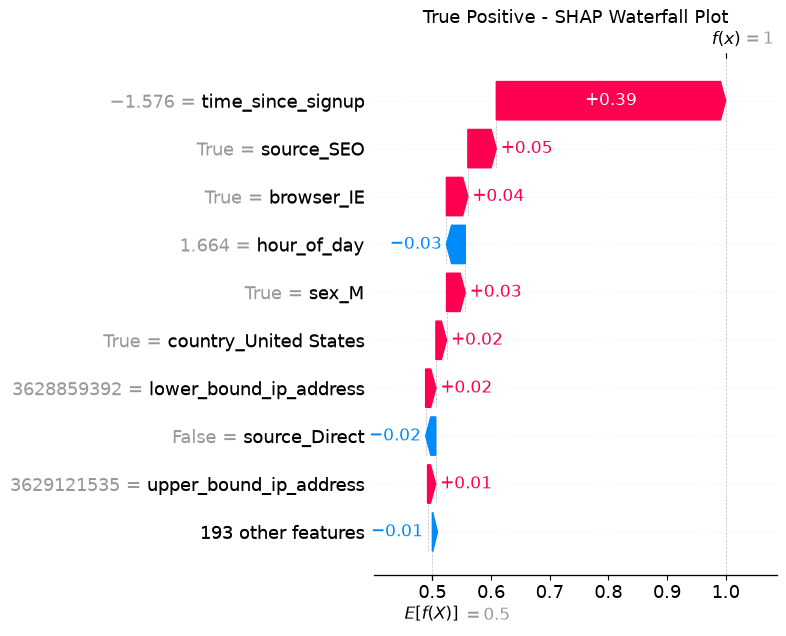

In [48]:
plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    tp_exp,
    max_display=10,
    show=False
)

plt.title("True Positive - SHAP Waterfall Plot")

plt.tight_layout()

plt.savefig(
    "../models/true_positive_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

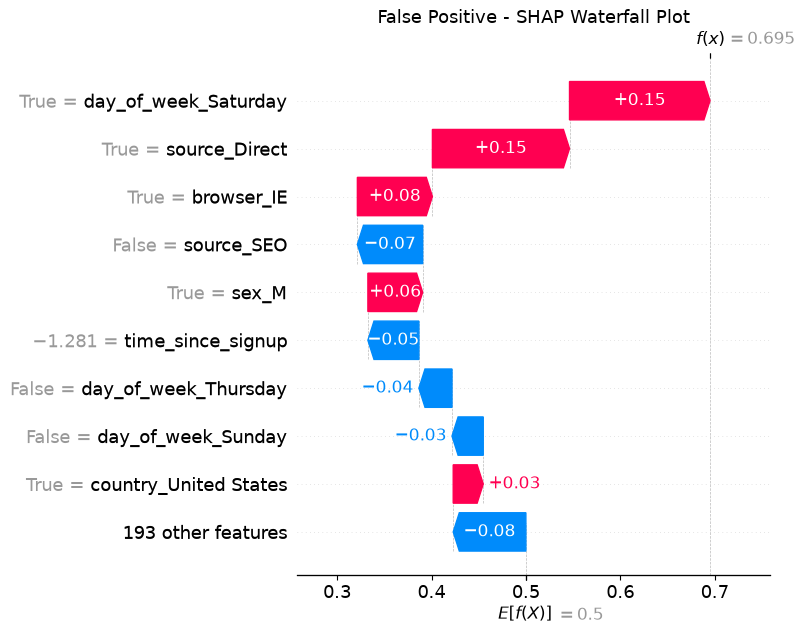

In [49]:
plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    fp_exp,
    max_display=10,
    show=False
)

plt.title("False Positive - SHAP Waterfall Plot")

plt.tight_layout()

plt.savefig(
    "../models/false_positive_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

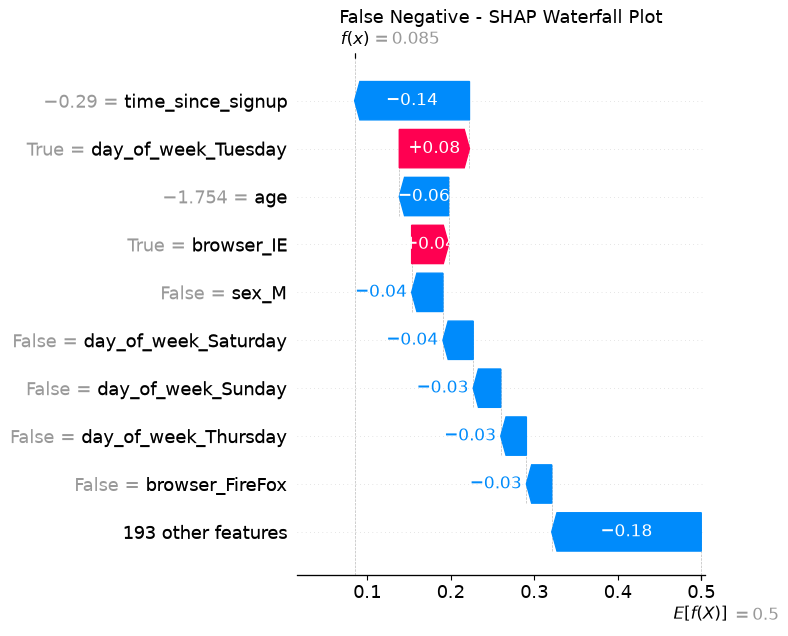

In [50]:
plt.figure(figsize=(10, 6))

shap.plots.waterfall(
    fn_exp,
    max_display=10,
    show=False
)

plt.title("False Negative - SHAP Waterfall Plot")

plt.tight_layout()

plt.savefig(
    "../models/false_negative_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
tp_features = pd.DataFrame({
    "Feature": X_explain.columns,
    "SHAP Value": shap_explain[0]
})

tp_features["Absolute SHAP"] = tp_features["SHAP Value"].abs()

tp_features = tp_features.sort_values(
    by="Absolute SHAP",
    ascending=False
)

print("Top Features - True Positive")

tp_features.head(10)

Top Features - True Positive


,Feature,SHAP Value,Absolute SHAP
6,time_since_signup,0.391044,0.391044
10,source_SEO,0.048462,0.048462
12,browser_IE,0.036575,0.036575
5,hour_of_day,-0.032122,0.032122
15,sex_M,0.031851,0.031851
186,country_United States,0.018176,0.018176
3,lower_bound_ip_address,0.017499,0.017499
9,source_Direct,-0.017132,0.017132
4,upper_bound_ip_address,0.013873,0.013873
14,browser_Safari,-0.010596,0.010596


In [52]:
fp_features = pd.DataFrame({
    "Feature": X_explain.columns,
    "SHAP Value": shap_explain[1]
})

fp_features["Absolute SHAP"] = fp_features["SHAP Value"].abs()

fp_features = fp_features.sort_values(
    by="Absolute SHAP",
    ascending=False
)

print("Top Features - False Positive")

fp_features.head(10)

Top Features - False Positive


,Feature,SHAP Value,Absolute SHAP
197,day_of_week_Saturday,0.148845,0.148845
9,source_Direct,0.145223,0.145223
12,browser_IE,0.079479,0.079479
10,source_SEO,-0.069171,0.069171
15,sex_M,0.058030,0.058030
6,time_since_signup,-0.054033,0.054033
199,day_of_week_Thursday,-0.035063,0.035063
198,day_of_week_Sunday,-0.033103,0.033103
186,country_United States,0.031821,0.031821
14,browser_Safari,-0.030759,0.030759


In [53]:
fn_features = pd.DataFrame({
    "Feature": X_explain.columns,
    "SHAP Value": shap_explain[2]
})

fn_features["Absolute SHAP"] = fn_features["SHAP Value"].abs()

fn_features = fn_features.sort_values(
    by="Absolute SHAP",
    ascending=False
)

print("Top Features - False Negative")

fn_features.head(10)

Top Features - False Negative


,Feature,SHAP Value,Absolute SHAP
6,time_since_signup,-0.137535,0.137535
200,day_of_week_Tuesday,0.084061,0.084061
1,age,-0.059039,0.059039
12,browser_IE,0.044244,0.044244
15,sex_M,-0.037456,0.037456
197,day_of_week_Saturday,-0.036263,0.036263
198,day_of_week_Sunday,-0.032989,0.032989
199,day_of_week_Thursday,-0.030673,0.030673
11,browser_FireFox,-0.030337,0.030337
196,day_of_week_Monday,-0.029329,0.029329


In [54]:
feature_importance.head(10)

,Feature,Importance
6,time_since_signup,0.304621
2,ip_address,0.063693
3,lower_bound_ip_address,0.059854
4,upper_bound_ip_address,0.059691
5,hour_of_day,0.056222
1,age,0.053263
0,purchase_value,0.052634
9,source_Direct,0.027518
10,source_SEO,0.024643
197,day_of_week_Saturday,0.023687


In [55]:
shap_importance.head(10)

,Feature,Mean_SHAP
6,time_since_signup,0.161270
9,source_Direct,0.048273
10,source_SEO,0.048211
198,day_of_week_Sunday,0.043189
197,day_of_week_Saturday,0.043053
199,day_of_week_Thursday,0.040505
196,day_of_week_Monday,0.035533
200,day_of_week_Tuesday,0.034677
15,sex_M,0.034390
12,browser_IE,0.031462


In [56]:
tp_features.head(10)

,Feature,SHAP Value,Absolute SHAP
6,time_since_signup,0.391044,0.391044
10,source_SEO,0.048462,0.048462
12,browser_IE,0.036575,0.036575
5,hour_of_day,-0.032122,0.032122
15,sex_M,0.031851,0.031851
186,country_United States,0.018176,0.018176
3,lower_bound_ip_address,0.017499,0.017499
9,source_Direct,-0.017132,0.017132
4,upper_bound_ip_address,0.013873,0.013873
14,browser_Safari,-0.010596,0.010596


In [57]:
fp_features.head(10)

,Feature,SHAP Value,Absolute SHAP
197,day_of_week_Saturday,0.148845,0.148845
9,source_Direct,0.145223,0.145223
12,browser_IE,0.079479,0.079479
10,source_SEO,-0.069171,0.069171
15,sex_M,0.058030,0.058030
6,time_since_signup,-0.054033,0.054033
199,day_of_week_Thursday,-0.035063,0.035063
198,day_of_week_Sunday,-0.033103,0.033103
186,country_United States,0.031821,0.031821
14,browser_Safari,-0.030759,0.030759


In [58]:
fn_features.head(10)

,Feature,SHAP Value,Absolute SHAP
6,time_since_signup,-0.137535,0.137535
200,day_of_week_Tuesday,0.084061,0.084061
1,age,-0.059039,0.059039
12,browser_IE,0.044244,0.044244
15,sex_M,-0.037456,0.037456
197,day_of_week_Saturday,-0.036263,0.036263
198,day_of_week_Sunday,-0.032989,0.032989
199,day_of_week_Thursday,-0.030673,0.030673
11,browser_FireFox,-0.030337,0.030337
196,day_of_week_Monday,-0.029329,0.029329


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     23376
           1       0.95      0.55      0.70      2454

    accuracy                           0.95     25830
   macro avg       0.95      0.77      0.84     25830
weighted avg       0.95      0.95      0.95     25830

